# Paper figures

## imports

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

from figutils import cm, set_figure_style

set_figure_style()

PAL_MODALITIES = {
    "rna_seq":          "#717EC3",
    "splice_site":      "#AE8799",
    "splice_usage":     "#C95D63",
    "splice_junctions": "#EE8434",
}

PAL_SAMPLES = {
    "WT":    "#C5CBD3",
    "K700E": "#8D6A9F",
}

PAL_MODELS = {
    "AlphaGenome": "#717EC3",
    "Pangolin":    "#C95D63",
}

PAL_RESOLUTION = {
    "1bp":  "#717EC3",
    "32bp": "#EE8434",
}

In [2]:
def plot_pearson_bars(data, title, outfile, ylabel="Pearson r", aspect=None, hue=None, palette=None):
    col_order    = [SUBSET_LABELS[s] for s in SUBSETS]
    sample_order = list(SAMPLE_LABELS.values())
    has_n = "n" in data.columns

    if hue is None and "model" in data.columns:
        hue = "model"
    has_hue = hue is not None
    if has_hue and palette is None:
        palette = PAL_MODELS
    hue_order = list(palette.keys()) if has_hue else None
    if aspect is None:
        aspect = 0.9 if has_hue else 0.6

    g = sns.catplot(
        data=data,
        kind="bar",
        x="sample", y="pearson_r",
        hue=hue if has_hue else None,
        hue_order=hue_order,
        col="subset_label",
        col_order=col_order,
        order=sample_order,
        palette=palette if has_hue else PAL_SAMPLES,
        width=0.6,
        height=4 * cm,
        aspect=aspect,
        legend=has_hue,
    )
    g.set_axis_labels("", ylabel)
    g.set_titles("{col_name}")
    g.set(ylim=(0, 1.05))
    for ax in g.axes.flat:
        subset_label = ax.get_title()
        if has_hue:
            for hue_idx, container in enumerate(ax.containers):
                hue_val = hue_order[hue_idx]
                for bar_idx, bar in enumerate(container):
                    sample = sample_order[bar_idx]
                    h = bar.get_height()
                    cx = bar.get_x() + bar.get_width() / 2
                    ax.text(cx, h + 0.02, "{:.3f}".format(h),
                            ha="center", va="bottom", fontsize=5)
                    if has_n:
                        row = data[
                            (data["subset_label"] == subset_label)
                            & (data["sample"] == sample)
                            & (data[hue] == hue_val)
                        ]
                        n = int(row["n"].values[0])
                        ax.text(cx, 0.02, "n={:,}".format(n),
                                ha="center", va="bottom", fontsize=4,
                                rotation=90, color="white")
        else:
            for bar_idx, bar in enumerate(ax.patches):
                sample = sample_order[bar_idx]
                h = bar.get_height()
                cx = bar.get_x() + bar.get_width() / 2
                # Pearson r above bar
                ax.text(cx, h + 0.02, "{:.3f}".format(h),
                        ha="center", va="bottom", fontsize=6)
                # n= rotated vertically at the bottom of the bar
                if has_n:
                    row = data[
                        (data["subset_label"] == subset_label) & (data["sample"] == sample)
                    ]
                    n = int(row["n"].values[0])
                    ax.text(cx, 0.02, "n={:,}".format(n),
                            ha="center", va="bottom", fontsize=5,
                            rotation=90, color="white")
    if has_hue:
        sns.move_legend(g, "center left", bbox_to_anchor=(1, 0.5), frameon=False, fontsize=5, title=None)
        g.figure.subplots_adjust(right=0.82)
    else:
        plt.tight_layout()
    g.figure.suptitle(title, y=1.04)
    g.figure.savefig(outfile, bbox_inches="tight")
    plt.show()
    print("saved:", outfile)

## data

In [3]:
ROOT     = ".."
EVAL_DIR = os.path.join(ROOT, "results", "bsc", "evaluation", "alphagenome_pytorch", "full")

PANGOLIN_EVAL_DIR = os.path.join(ROOT, "results", "evaluation", "pangolin", "full")
PANGOLIN_RUN_NAME = "annotated__frozen__1gpu"
PANGOLIN_EPOCH    = 5

OUTPUT_DIR = os.path.join("pdfs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

RUN_NAME  = "randinit__newloss__annotated__frozen__multigpu_ddp"
EPOCH     = 10
SUBSETS   = ["test", "train_sample"]

SAMPLE_LABELS = {
    "SRR17111303": "WT",
    "SRR17111311": "K700E",
}

SUBSET_LABELS = {
    "test":         "Test intervals",
    "train_sample": "Train sample",
}

In [4]:
def per_gene_pearson_rows(rna_df, resolution_label):
    rows = []
    for sample_id, sample_label in SAMPLE_LABELS.items():
        sub = rna_df[rna_df["track_name"] == sample_id].dropna(subset=["pred_log_mean", "obs_log_mean"])
        r, _ = stats.pearsonr(sub["obs_log_mean"], sub["pred_log_mean"])
        rows.append({"sample": sample_label, "pearson_r": float(r), "n": len(sub), "resolution": resolution_label})
    return rows


records = []
for subset in SUBSETS:
    pred_dir = os.path.join(EVAL_DIR, RUN_NAME, "epoch{}".format(EPOCH), subset, "predictions")
    rna_1bp  = pd.read_parquet(os.path.join(pred_dir, "rna_seq_per_gene.parquet"))
    rna_32bp = pd.read_parquet(os.path.join(pred_dir, "rna_seq_per_gene_32bp.parquet"))
    for res_label, rna_df in [("1bp", rna_1bp), ("32bp", rna_32bp)]:
        for row in per_gene_pearson_rows(rna_df, res_label):
            row["subset"] = subset
            records.append(row)

metrics = pd.DataFrame(records)
metrics["subset_label"] = metrics["subset"].map(SUBSET_LABELS)
print(metrics)

  sample  pearson_r      n resolution        subset    subset_label
0     WT   0.901071   6631        1bp          test  Test intervals
1  K700E   0.897334   6631        1bp          test  Test intervals
2     WT   0.897593   6631       32bp          test  Test intervals
3  K700E   0.894001   6631       32bp          test  Test intervals
4     WT   0.958537  46092        1bp  train_sample    Train sample
5  K700E   0.953478  46092        1bp  train_sample    Train sample
6     WT   0.955774  46092       32bp  train_sample    Train sample
7  K700E   0.950871  46092       32bp  train_sample    Train sample


## figures

### gene expression — per-gene mean coverage, 1bp vs 32bp, faceted by interval subset

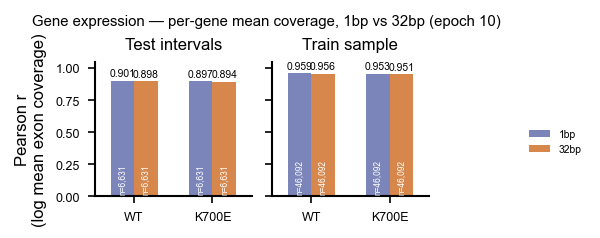

saved: pdfs/gene_expr_pearson_epoch10.pdf


In [5]:
plot_pearson_bars(
    data=metrics,
    title="Gene expression — per-gene mean coverage, 1bp vs 32bp (epoch {})".format(EPOCH),
    outfile=os.path.join(OUTPUT_DIR, "gene_expr_pearson_epoch{}.pdf".format(EPOCH)),
    ylabel="Pearson r\n(log mean exon coverage)",
    hue="resolution",
    palette=PAL_RESOLUTION,
)

### gene expression coverage — per-position profile correlation, 1bp vs 32bp, faceted by interval subset

Unlike the per-gene panel above (one Pearson r per gene, computed from its mean exon
coverage), this uses `rna_seq_profile_corr_exon_{1bp,32bp}.parquet` -- Pearson r computed
directly over every log1p(coverage) exon *position* (pooled across all test genes), at
native 1bp resolution vs 32bp-binned (Borzoi-comparable) resolution. Forward/reverse
strand tracks are averaged per sample.

In [6]:
def profile_corr_rows(pred_dir, scope, resolution_label):
    fpath = os.path.join(pred_dir, "rna_seq_profile_corr_{}_{}.parquet".format(scope, resolution_label))
    df = pd.read_parquet(fpath)
    rows = []
    for track_name, sub in df.groupby("track_name"):
        sample_label = SAMPLE_LABELS.get(track_name, track_name)
        rows.append({
            "sample": sample_label,
            "pearson_r": float(sub["pearson_r"].mean()),
            "n": int(sub["n_positions"].sum()),
            "resolution": resolution_label,
        })
    return rows


PROFILE_SCOPE = "exon"  # matches the per-gene exon-mean panel above; "full" also available (whole test interval)

records = []
for subset in SUBSETS:
    pred_dir = os.path.join(EVAL_DIR, RUN_NAME, "epoch{}".format(EPOCH), subset, "predictions")
    for res_label in ["1bp", "32bp"]:
        for row in profile_corr_rows(pred_dir, PROFILE_SCOPE, res_label):
            row["subset"] = subset
            records.append(row)

profile_metrics = pd.DataFrame(records)
profile_metrics["subset_label"] = profile_metrics["subset"].map(SUBSET_LABELS)
print(profile_metrics)

  sample  pearson_r          n resolution        subset    subset_label
0     WT   0.888376   59491902        1bp          test  Test intervals
1  K700E   0.887730   59491902        1bp          test  Test intervals
2     WT   0.890874    2004944       32bp          test  Test intervals
3  K700E   0.890131    2004944       32bp          test  Test intervals
4     WT   0.951018  394175378        1bp  train_sample    Train sample
5  K700E   0.947423  394175378        1bp  train_sample    Train sample
6     WT   0.952707   13272536       32bp  train_sample    Train sample
7  K700E   0.949066   13272536       32bp  train_sample    Train sample


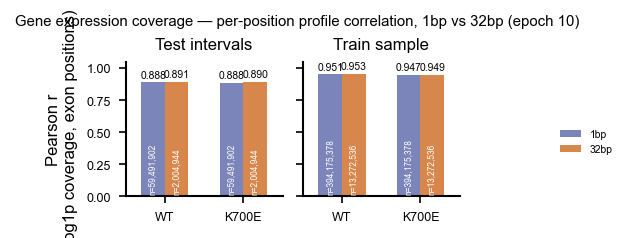

saved: pdfs/gene_expr_profile_corr_epoch10.pdf


In [7]:
plot_pearson_bars(
    data=profile_metrics,
    title="Gene expression coverage — per-position profile correlation, 1bp vs 32bp (epoch {})".format(EPOCH),
    outfile=os.path.join(OUTPUT_DIR, "gene_expr_profile_corr_epoch{}.pdf".format(EPOCH)),
    ylabel="Pearson r\n(log1p coverage, exon positions)",
    hue="resolution",
    palette=PAL_RESOLUTION,
)

### splice site usage (SSU) — Pearson r by sample, faceted by interval subset

In [8]:
def load_ssu_scores(eval_dir, run_name, epoch, subset, rename_pos=None):
    fpath = os.path.join(eval_dir, run_name, "epoch{}".format(epoch), subset, "predictions", "ssu_scores.parquet")
    df = pd.read_parquet(fpath)
    if rename_pos and rename_pos in df.columns:
        df = df.rename(columns={rename_pos: "exon_pos"})
    return df


def dedup_ssu_mean(df):
    """Collapse duplicate (site, sample) rows created by overlapping test-interval windows.

    test.bed intervals themselves overlap heavily (most consecutive intervals share
    coordinates), so both models emit multiple prediction rows per physical splice
    site -- one per test interval whose context window covers it. Averaging collapses
    each site down to a single row per sample.
    """
    key = ["chrom", "exon_pos", "strand", "sample_id"]
    return df.groupby(key, as_index=False).agg(
        pred_ssu=("pred_ssu", "mean"),
        obs_ssu=("obs_ssu", "mean"),
        alpha_juncs=("alpha_juncs", "max"),
    )


def common_sites(*dfs):
    """Intersection of (chrom, exon_pos, strand) splice sites present in every df."""
    sites = None
    for df in dfs:
        s = set(map(tuple, df[["chrom", "exon_pos", "strand"]].drop_duplicates().values.tolist()))
        sites = s if sites is None else (sites & s)
    return pd.DataFrame(list(sites), columns=["chrom", "exon_pos", "strand"])


def ssu_pearson_rows(df, model_name, chrom_filter=None):
    if chrom_filter is not None:
        df = df[df["chrom"].isin(chrom_filter)]
    rows = []
    for sample_id, sample_label in SAMPLE_LABELS.items():
        grp = df[df["sample_id"] == sample_id].dropna(subset=["pred_ssu", "obs_ssu"])
        r, _ = stats.pearsonr(grp["pred_ssu"].values, grp["obs_ssu"].values)
        rows.append({"sample": sample_label, "pearson_r": float(r), "n": len(grp), "model": model_name})
    return rows

In [9]:
records = []
for subset in SUBSETS:
    ag_df = load_ssu_scores(EVAL_DIR, RUN_NAME, EPOCH, subset, rename_pos="exon_pos_1based")
    pg_df = load_ssu_scores(PANGOLIN_EVAL_DIR, PANGOLIN_RUN_NAME, PANGOLIN_EPOCH, subset)

    ag_dedup = dedup_ssu_mean(ag_df)
    pg_dedup = dedup_ssu_mean(pg_df)

    sites = common_sites(ag_dedup, pg_dedup)
    ag_common = ag_dedup.merge(sites, on=["chrom", "exon_pos", "strand"], how="inner")
    pg_common = pg_dedup.merge(sites, on=["chrom", "exon_pos", "strand"], how="inner")

    for name, d in [("AlphaGenome", ag_common), ("Pangolin", pg_common)]:
        for row in ssu_pearson_rows(d, name):
            row["subset"] = subset
            records.append(row)

ssu_metrics = pd.DataFrame(records)
ssu_metrics["subset_label"] = ssu_metrics["subset"].map(SUBSET_LABELS)
print(ssu_metrics)

  sample  pearson_r       n        model        subset    subset_label
0     WT   0.719248   41821  AlphaGenome          test  Test intervals
1  K700E   0.589523   45090  AlphaGenome          test  Test intervals
2     WT   0.590767   41821     Pangolin          test  Test intervals
3  K700E   0.447871   45090     Pangolin          test  Test intervals
4     WT   0.761439  285953  AlphaGenome  train_sample    Train sample
5  K700E   0.653545  308475  AlphaGenome  train_sample    Train sample
6     WT   0.594346  285953     Pangolin  train_sample    Train sample
7  K700E   0.424357  308475     Pangolin  train_sample    Train sample


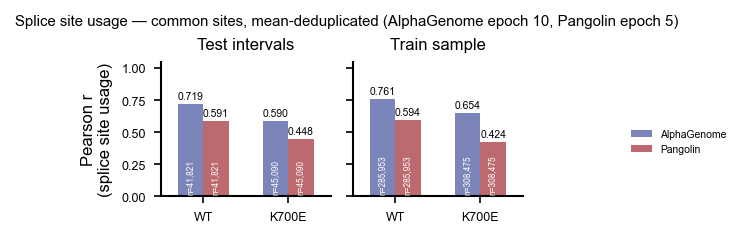

saved: pdfs/ssu_pearson_epoch10.pdf


In [10]:
plot_pearson_bars(
    data=ssu_metrics,
    title="Splice site usage — common sites, mean-deduplicated (AlphaGenome epoch {}, Pangolin epoch {})".format(EPOCH, PANGOLIN_EPOCH),
    outfile=os.path.join(OUTPUT_DIR, "ssu_pearson_epoch{}.pdf".format(EPOCH)),
    ylabel="Pearson r\n(splice site usage)",
)

### SSU — Pangolin test intervals (unseen chromosomes)

In [11]:
PANGOLIN_UNSEEN_CHROMS = {"chr1", "chr3", "chr5", "chr7", "chr9"}

records = []
for subset in SUBSETS:
    ag_df = load_ssu_scores(EVAL_DIR, RUN_NAME, EPOCH, subset, rename_pos="exon_pos_1based")
    pg_df = load_ssu_scores(PANGOLIN_EVAL_DIR, PANGOLIN_RUN_NAME, PANGOLIN_EPOCH, subset)

    ag_dedup = dedup_ssu_mean(ag_df)
    pg_dedup = dedup_ssu_mean(pg_df)

    sites = common_sites(ag_dedup, pg_dedup)
    ag_common = ag_dedup.merge(sites, on=["chrom", "exon_pos", "strand"], how="inner")
    pg_common = pg_dedup.merge(sites, on=["chrom", "exon_pos", "strand"], how="inner")

    for name, d in [("AlphaGenome", ag_common), ("Pangolin", pg_common)]:
        for row in ssu_pearson_rows(d, name, chrom_filter=PANGOLIN_UNSEEN_CHROMS):
            row["subset"] = subset
            records.append(row)

ssu_pangolin_metrics = pd.DataFrame(records)
ssu_pangolin_metrics["subset_label"] = ssu_pangolin_metrics["subset"].map(SUBSET_LABELS)
print(ssu_pangolin_metrics)

  sample  pearson_r      n        model        subset    subset_label
0     WT   0.758862   9214  AlphaGenome          test  Test intervals
1  K700E   0.638949   9926  AlphaGenome          test  Test intervals
2     WT   0.593989   9214     Pangolin          test  Test intervals
3  K700E   0.431613   9926     Pangolin          test  Test intervals
4     WT   0.759591  84049  AlphaGenome  train_sample    Train sample
5  K700E   0.646736  90903  AlphaGenome  train_sample    Train sample
6     WT   0.585522  84049     Pangolin  train_sample    Train sample
7  K700E   0.432179  90903     Pangolin  train_sample    Train sample


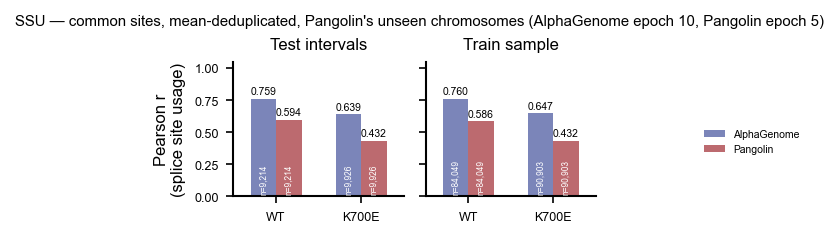

saved: pdfs/ssu_pearson_pangolin_unseen_epoch10.pdf


In [12]:
plot_pearson_bars(
    data=ssu_pangolin_metrics,
    title="SSU — common sites, mean-deduplicated, Pangolin's unseen chromosomes (AlphaGenome epoch {}, Pangolin epoch {})".format(EPOCH, PANGOLIN_EPOCH),
    outfile=os.path.join(OUTPUT_DIR, "ssu_pearson_pangolin_unseen_epoch{}.pdf".format(EPOCH)),
    ylabel="Pearson r\n(splice site usage)",
)

### junction counts — Pearson r by sample, faceted by interval subset

In [13]:
records = []
for subset in SUBSETS:
    pred_dir   = os.path.join(EVAL_DIR, RUN_NAME, "epoch{}".format(EPOCH), subset, "predictions")
    metrics_df = pd.read_parquet(os.path.join(EVAL_DIR, RUN_NAME, "epoch{}".format(EPOCH), subset, "metrics.parquet"))
    junc_df    = pd.read_parquet(os.path.join(pred_dir, "junction_scores.parquet"))
    for sample_id, sample_label in SAMPLE_LABELS.items():
        r = float(metrics_df.loc[metrics_df["metric_name"] == "junction_count_pearson_r_{}".format(sample_id), "value"].values[0])
        n = int(((junc_df["sample_id"] == sample_id) & (junc_df["obs_count"] > 0)).sum())
        records.append({"subset": subset, "sample": sample_label, "pearson_r": r, "n": n})

junc_metrics = pd.DataFrame(records)
junc_metrics["subset_label"] = junc_metrics["subset"].map(SUBSET_LABELS)
print(junc_metrics)

         subset sample  pearson_r       n    subset_label
0          test     WT   0.784472  587974  Test intervals
1          test  K700E   0.791204  641729  Test intervals
2  train_sample     WT   0.879412  656552    Train sample
3  train_sample  K700E   0.879419  717582    Train sample


/tmp/ipykernel_1964779/3305335358.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


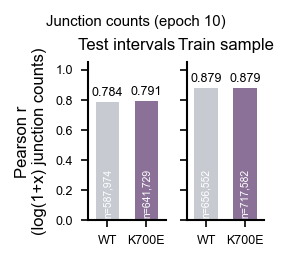

saved: pdfs/junction_count_pearson_epoch10.pdf


In [14]:
plot_pearson_bars(
    data=junc_metrics,
    title="Junction counts (epoch {})".format(EPOCH),
    outfile=os.path.join(OUTPUT_DIR, "junction_count_pearson_epoch{}.pdf".format(EPOCH)),
    ylabel="Pearson r\n(log(1+x) junction counts)",
)